# 🎬 Netflix Content Intelligence & Recommendation Platform
---
**Problem Statement:** OTT platforms like Netflix face three persistent challenges:
1. **Content Discovery** — Users churn when they can't find what to watch. Netflix itself estimates it loses ~\$1B/year to churn.
2. **Content Strategy Blind Spots** — Which genres are oversaturated? Which regions are underserved? Where should acquisition \$ go?
3. **Catalog Staleness** — How is the content library aging, and what does the release pipeline look like?

This pipeline ingests raw Netflix catalog data, cleans and enriches it through a **local Medallion Architecture** (Bronze → Silver → Gold), then builds:
- **Analytical dashboards** exposing content gaps, regional imbalances, and genre saturation
- **A content-based recommendation engine** using TF-IDF + metadata similarity
- **An interactive UI** to test recommendations live

> **Architecture:** Pandas (ingestion) → Bronze (raw parquet) → Silver (cleaned, joined, typed) → Gold (aggregated, ML-ready) → Sklearn (model) → Matplotlib + ipywidgets (UI)

---

## 0 · Environment Setup

In [28]:
# ── Installs (run once) ──────────────────────────────────────────────
# !pip install pandas numpy scikit-learn matplotlib seaborn ipywidgets scipy pyarrow
# If you're on JupyterLab, also run:
# !jupyter labextension install @jupyter-widgets/jupyterlab-manager

In [29]:
import warnings
warnings.filterwarnings("ignore")

import os, re, json, textwrap
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Plot style (Netflix dark theme) ─────────────────────────────────
plt.style.use("dark_background")
sns.set_palette("Reds_r")
NETFLIX_RED = "#E50914"
NETFLIX_GRAY = "#564d4d"
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "figure.facecolor": "#141414",
    "axes.facecolor": "#1a1a1a",
    "savefig.facecolor": "#141414",
    "font.family": "sans-serif",
})

print("✅ All imports loaded.")


✅ All imports loaded.


In [30]:
# ── Configuration ───────────────────────────────────────────────────
# Point these to wherever you saved the CSV files.
# The notebook expects them all in the same directory.

DATA_DIR   = Path("./data/raw")         # <-- change if needed
BRONZE_DIR = Path("./data/bronze")
SILVER_DIR = Path("./data/silver")
GOLD_DIR   = Path("./data/gold")
MODEL_DIR  = Path("./models")

for d in [BRONZE_DIR, SILVER_DIR, GOLD_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# File manifest — edit filenames if yours differ
FILES = {
    "titles":     DATA_DIR / "netflix_titles.csv",
    "directors":  DATA_DIR / "netflix_directors.csv",
    "cast":       DATA_DIR / "netflix_cast.csv",
    "categories": DATA_DIR / "netflix_category.csv",
    "countries":  DATA_DIR / "netflix_countries.csv",
}

print("📁 Directory structure ready.")
print(f"   Raw data expected in: {DATA_DIR.resolve()}")

📁 Directory structure ready.
   Raw data expected in: /Users/ajaykumar/Desktop/netflix_project/data/raw


---
## 1 · Bronze Layer — Raw Ingestion with Validation
The Bronze layer mirrors the source data *as-is* in a more efficient format (Parquet), adding ingestion metadata for lineage tracking. No transformations happen here — just load, validate schema, and persist.

In [31]:
def ingest_to_bronze(name: str, filepath: Path) -> pd.DataFrame:
    """
    Read a raw CSV, attach ingestion metadata, save as Parquet in Bronze.
    Returns the raw DataFrame for inspection.
    """
    if not filepath.exists():
        raise FileNotFoundError(f"Missing: {filepath}  — check DATA_DIR and filenames.")

    df = pd.read_csv(filepath, encoding="utf-8-sig")

    # ── Lineage metadata ────────────────────────────────────────
    df["_ingested_at"]   = datetime.utcnow().isoformat()
    df["_source_file"]   = filepath.name
    df["_record_count"]  = len(df)

    # ── Persist to Bronze (parquet, snappy compression) ─────────
    out = BRONZE_DIR / f"{name}.parquet"
    df.to_parquet(out, index=False, engine="pyarrow")

    print(f"  ✅ {name:15s} | {len(df):>6,} rows | {df.shape[1]} cols → {out.name}")
    return df


print("Ingesting raw CSVs into Bronze…\n")
bronze = {}
for name, path in FILES.items():
    bronze[name] = ingest_to_bronze(name, path)

print("\n🥉 Bronze layer complete.")

Ingesting raw CSVs into Bronze…

  ✅ titles          |  6,236 rows | 12 cols → titles.parquet
  ✅ directors       |  4,852 rows | 5 cols → directors.parquet
  ✅ cast            | 44,311 rows | 5 cols → cast.parquet
  ✅ categories      | 13,670 rows | 5 cols → categories.parquet
  ✅ countries       |  7,179 rows | 5 cols → countries.parquet

🥉 Bronze layer complete.


In [32]:
# Quick schema check — catch problems early
for name, df in bronze.items():
    nulls = df.isnull().sum()
    bad = nulls[nulls > 0]
    if len(bad):
        print(f"⚠️  {name}: nulls detected → {dict(bad)}")
    else:
        print(f"✓  {name}: no nulls")

⚠️  titles: nulls detected → {'duration_minutes': np.int64(1969), 'duration_seasons': np.int64(4265), 'type': np.int64(1), 'title': np.int64(1), 'date_added': np.int64(13), 'release_year': np.int64(2), 'rating': np.int64(13), 'description': np.int64(3), 'show_id': np.int64(4)}
✓  directors: no nulls
✓  cast: no nulls
✓  categories: no nulls
✓  countries: no nulls


---
## 2 · Silver Layer — Cleaning, Joining & Feature Engineering
This is where the real work happens. We:
1. Clean and type-cast the titles table
2. Aggregate the lookup tables (directors, cast, categories, countries) by `show_id`
3. Join everything into a single **enriched** Silver table
4. Engineer features needed downstream (decade, content age, description length, etc.)

In [33]:
# ── 2a. Clean the titles table ──────────────────────────────────────

df_titles = bronze["titles"].copy()

# Drop ingestion metadata cols for processing
meta_cols = [c for c in df_titles.columns if c.startswith("_")]
df_titles.drop(columns=meta_cols, inplace=True)

# Cast types
df_titles["duration_minutes"] = pd.to_numeric(df_titles["duration_minutes"], errors="coerce").fillna(0).astype(int)
df_titles["duration_seasons"] = pd.to_numeric(df_titles["duration_seasons"], errors="coerce").fillna(1).astype(int)
df_titles["release_year"]     = pd.to_numeric(df_titles["release_year"], errors="coerce").astype("Int64")

# Parse date_added
df_titles["date_added"] = pd.to_datetime(df_titles["date_added"], errors="coerce")
df_titles["year_added"] = df_titles["date_added"].dt.year.astype("Int64")
df_titles["month_added"] = df_titles["date_added"].dt.month.astype("Int64")

# Normalize rating — take first part before hyphen
df_titles["rating"] = df_titles["rating"].astype(str).str.split("-").str[0].str.strip()
df_titles["rating"] = df_titles["rating"].replace("nan", np.nan)

# Clean title
df_titles["title_clean"] = df_titles["title"].astype(str).str.strip()

# Content age (years since release)
current_year = datetime.now().year
df_titles["content_age"] = current_year - df_titles["release_year"]

# Decade bucket
df_titles["decade"] = (df_titles["release_year"] // 10 * 10).astype("Int64")

# Description length (proxy for richness of metadata)
df_titles["desc_length"] = df_titles["description"].astype(str).str.len()

# Type flag
df_titles["type_flag"] = df_titles["type"].map({"Movie": 1, "TV Show": 2}).fillna(0).astype(int)

print(f"Titles cleaned: {df_titles.shape}")
df_titles.head(3)

Titles cleaned: (6236, 16)


,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,year_added,month_added,title_clean,content_age,decade,desc_length,type_flag
0,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019,TV,Before planning an awesome wedding for his gra...,81145628.0,2019,9,Norm of the North: King Sized Adventure,7,2010,140,1
1,94,1,Movie,Jandino: Whatever it Takes,2016-09-09,2016,TV,Jandino Asporaat riffs on the challenges of ra...,80117401.0,2016,9,Jandino: Whatever it Takes,10,2010,145,1
2,0,1,TV Show,Transformers Prime,2018-09-08,2013,TV,"With the help of three human allies, the Autob...",70234439.0,2018,9,Transformers Prime,13,2010,140,2


In [34]:
# ── 2b. Aggregate lookup tables by show_id ─────────────────────────

def aggregate_lookup(df: pd.DataFrame, value_col: str, new_col: str) -> pd.DataFrame:
    """Group a lookup table by show_id, collecting values into a list and a pipe-separated string."""
    df = df.drop(columns=[c for c in df.columns if c.startswith("_")], errors="ignore")
    agg = df.groupby("show_id")[value_col].apply(list).reset_index()
    agg.rename(columns={value_col: f"{new_col}_list"}, inplace=True)
    agg[f"{new_col}_str"] = agg[f"{new_col}_list"].apply(lambda x: " | ".join(str(i) for i in x))
    agg[f"{new_col}_count"] = agg[f"{new_col}_list"].apply(len)
    return agg

lookup_directors  = aggregate_lookup(bronze["directors"],  "director",  "director")
lookup_cast       = aggregate_lookup(bronze["cast"],       "cast",      "cast")
lookup_categories = aggregate_lookup(bronze["categories"], "listed_in", "genre")
lookup_countries  = aggregate_lookup(bronze["countries"],  "country",   "country")

print("Lookup tables aggregated:")
for name, df in [("directors", lookup_directors), ("cast", lookup_cast),
                 ("categories", lookup_categories), ("countries", lookup_countries)]:
    print(f"  {name:12s}: {len(df):>5,} unique show_ids")

Lookup tables aggregated:
  directors   : 4,265 unique show_ids
  cast        : 5,664 unique show_ids
  categories  : 6,234 unique show_ids
  countries   : 5,758 unique show_ids


In [35]:
# ── 2c. Join into enriched Silver table ─────────────────────────────

silver = (
    df_titles
    .merge(lookup_directors,  on="show_id", how="left")
    .merge(lookup_cast,       on="show_id", how="left")
    .merge(lookup_categories, on="show_id", how="left")
    .merge(lookup_countries,  on="show_id", how="left")
)

# Fill NaN lists with empty lists
for col in ["director_list", "cast_list", "genre_list", "country_list"]:
    silver[col] = silver[col].apply(lambda x: x if isinstance(x, list) else [])

for col in ["director_str", "cast_str", "genre_str", "country_str"]:
    silver[col] = silver[col].fillna("")

for col in ["director_count", "cast_count", "genre_count", "country_count"]:
    silver[col] = silver[col].fillna(0).astype(int)

# Deduplicate on show_id (safety net)
before = len(silver)
silver.drop_duplicates(subset=["show_id"], inplace=True)
after = len(silver)
if before != after:
    print(f"⚠️  Removed {before - after} duplicate show_ids")

# Persist
silver.to_parquet(SILVER_DIR / "netflix_enriched.parquet", index=False)

print(f"\n🥈 Silver layer complete: {silver.shape[0]:,} titles × {silver.shape[1]} columns")
silver.head(3)

⚠️  Removed 3 duplicate show_ids

🥈 Silver layer complete: 6,233 titles × 28 columns


,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,year_added,...,director_count,cast_list,cast_str,cast_count,genre_list,genre_str,genre_count,country_list,country_str,country_count
0,90,1,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019,TV,Before planning an awesome wedding for his gra...,81145628.0,2019,...,2,"[Alan Marriott, Jennifer Cameron, Lee Tockar, ...",Alan Marriott | Jennifer Cameron | Lee Tockar ...,10,"[Children & Family Movies, Comedies]",Children & Family Movies | Comedies,2,"[United States, China, India, South Korea]",United States | China | India | South Korea,4
1,94,1,Movie,Jandino: Whatever it Takes,2016-09-09,2016,TV,Jandino Asporaat riffs on the challenges of ra...,80117401.0,2016,...,0,[Jandino Asporaat],Jandino Asporaat,1,[Stand-Up Comedy],Stand-Up Comedy,1,[United Kingdom],United Kingdom,1
2,0,1,TV Show,Transformers Prime,2018-09-08,2013,TV,"With the help of three human allies, the Autob...",70234439.0,2018,...,0,"[Peter Cullen, Kevin Michael Richardson, Josh ...",Peter Cullen | Kevin Michael Richardson | Josh...,12,[Kids' TV],Kids' TV,1,[United States],United States,1


---
## 3 · Gold Layer — Business-Ready Aggregations
Pre-computed analytics tables that answer specific business questions. These would feed dashboards or APIs in production.

In [36]:
# ── 3a. Genre popularity over time ──────────────────────────────────

genre_exploded = silver.explode("genre_list")[["show_id", "genre_list", "year_added", "type"]].dropna(subset=["genre_list", "year_added"])
genre_exploded.rename(columns={"genre_list": "genre"}, inplace=True)
genre_exploded["genre"] = genre_exploded["genre"].str.strip()

gold_genre_trend = (
    genre_exploded
    .groupby(["year_added", "genre", "type"])
    .agg(title_count=("show_id", "nunique"))
    .reset_index()
)
gold_genre_trend.to_parquet(GOLD_DIR / "genre_trend.parquet", index=False)
print(f"✅ genre_trend: {len(gold_genre_trend):,} rows")

✅ genre_trend: 289 rows


In [37]:
# ── 3b. Country content volume ──────────────────────────────────────

country_exploded = silver.explode("country_list")[["show_id", "country_list", "type", "release_year"]].dropna(subset=["country_list"])
country_exploded.rename(columns={"country_list": "country"}, inplace=True)
country_exploded["country"] = country_exploded["country"].str.strip()

gold_country = (
    country_exploded
    .groupby(["country", "type"])
    .agg(title_count=("show_id", "nunique"), avg_year=("release_year", "mean"))
    .reset_index()
    .sort_values("title_count", ascending=False)
)
gold_country.to_parquet(GOLD_DIR / "country_volume.parquet", index=False)
print(f"✅ country_volume: {len(gold_country):,} rows")

✅ country_volume: 166 rows


In [38]:
# ── 3c. Content freshness / aging analysis ─────────────────────────

gold_freshness = (
    silver
    .groupby(["decade", "type"])
    .agg(
        title_count=("show_id", "nunique"),
        avg_duration_min=("duration_minutes", "mean"),
        avg_seasons=("duration_seasons", "mean"),
    )
    .reset_index()
)
gold_freshness.to_parquet(GOLD_DIR / "content_freshness.parquet", index=False)
print(f"✅ content_freshness: {len(gold_freshness):,} rows")

✅ content_freshness: 18 rows


In [39]:
# ── 3d. Rating distribution ─────────────────────────────────────────

gold_rating = (
    silver
    .groupby(["rating", "type"])
    .agg(title_count=("show_id", "nunique"))
    .reset_index()
    .sort_values("title_count", ascending=False)
)
gold_rating.to_parquet(GOLD_DIR / "rating_distribution.parquet", index=False)

print(f"✅ rating_distribution: {len(gold_rating):,} rows")
print("\n🥇 Gold layer complete.")

✅ rating_distribution: 12 rows

🥇 Gold layer complete.


---
## 4 · Analytical Dashboards
Interactive Plotly charts exposing content strategy insights.

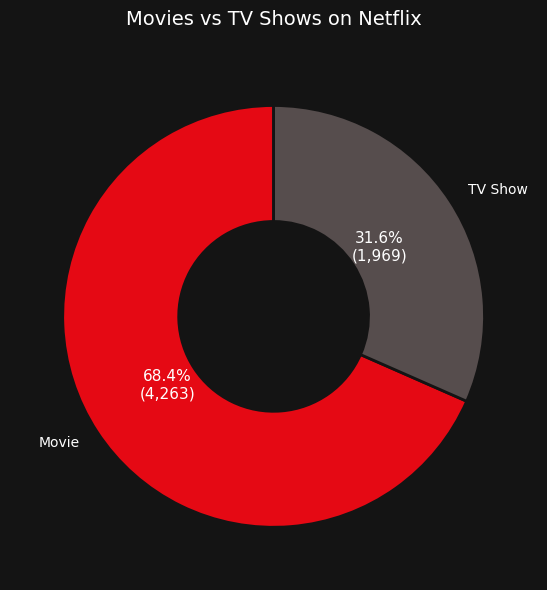

In [40]:
# ── 4a. Content type split ──────────────────────────────────────────

type_counts = silver["type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct=lambda p: f"{p:.1f}%\n({int(p * sum(type_counts.values) / 100):,})",
    colors=[NETFLIX_RED, NETFLIX_GRAY],
    startangle=90,
    pctdistance=0.6,
    wedgeprops={"width": 0.55, "edgecolor": "#141414", "linewidth": 2},
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_color("white")
ax.set_title("Movies vs TV Shows on Netflix", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


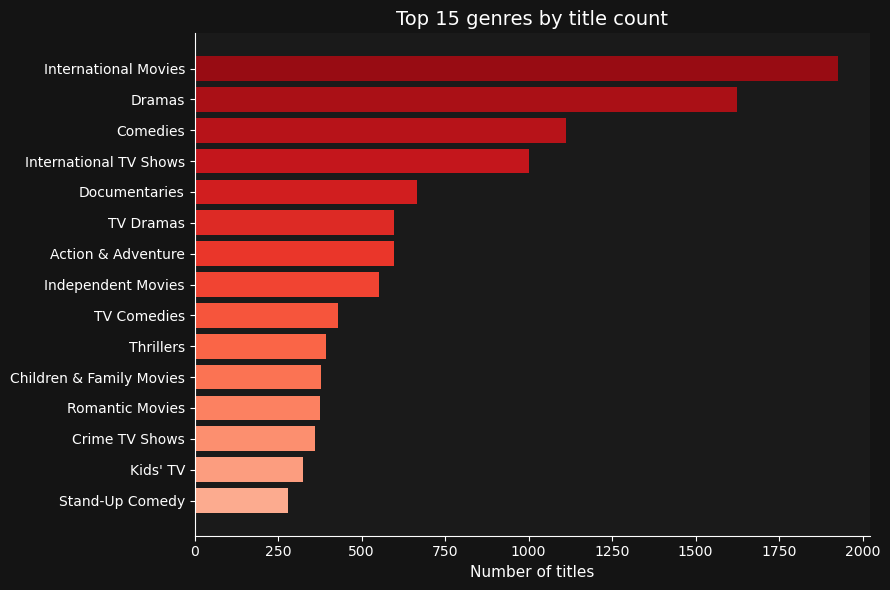

In [41]:
# ── 4b. Top 15 genres ──────────────────────────────────────────────

top_genres = (
    genre_exploded.groupby("genre")["show_id"].nunique()
    .sort_values(ascending=True).tail(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_genres)))
ax.barh(top_genres.index, top_genres.values, color=colors)
ax.set_xlabel("Number of titles")
ax.set_title("Top 15 genres by title count")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


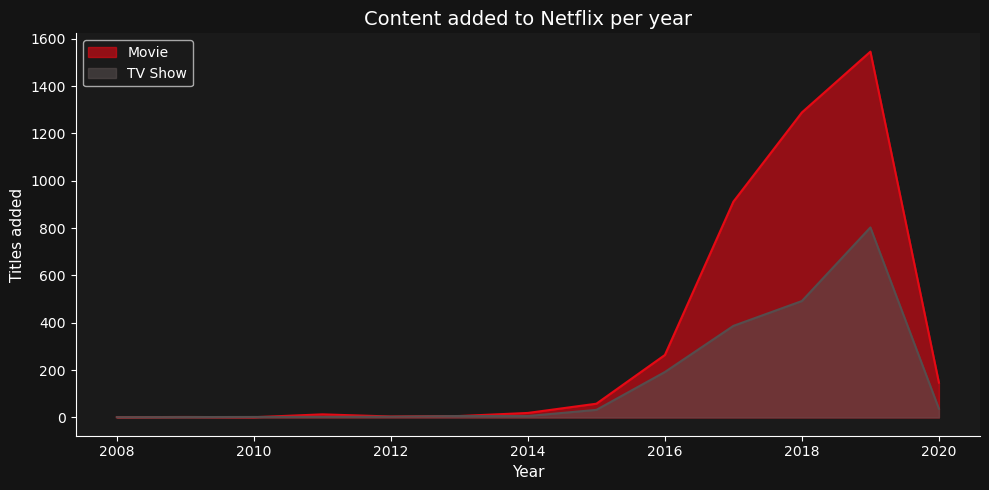

In [42]:
# ── 4c. Content additions over time ────────────────────────────────

yearly = silver.groupby(["year_added", "type"])["show_id"].nunique().reset_index()
yearly.columns = ["year", "type", "titles"]
yearly = yearly.dropna(subset=["year"])

fig, ax = plt.subplots(figsize=(10, 5))
for ttype, color in [("Movie", NETFLIX_RED), ("TV Show", NETFLIX_GRAY)]:
    subset = yearly[yearly["type"] == ttype].sort_values("year")
    ax.fill_between(subset["year"], subset["titles"], alpha=0.6, color=color, label=ttype)
    ax.plot(subset["year"], subset["titles"], color=color, linewidth=1.5)
ax.set_xlabel("Year")
ax.set_ylabel("Titles added")
ax.set_title("Content added to Netflix per year")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


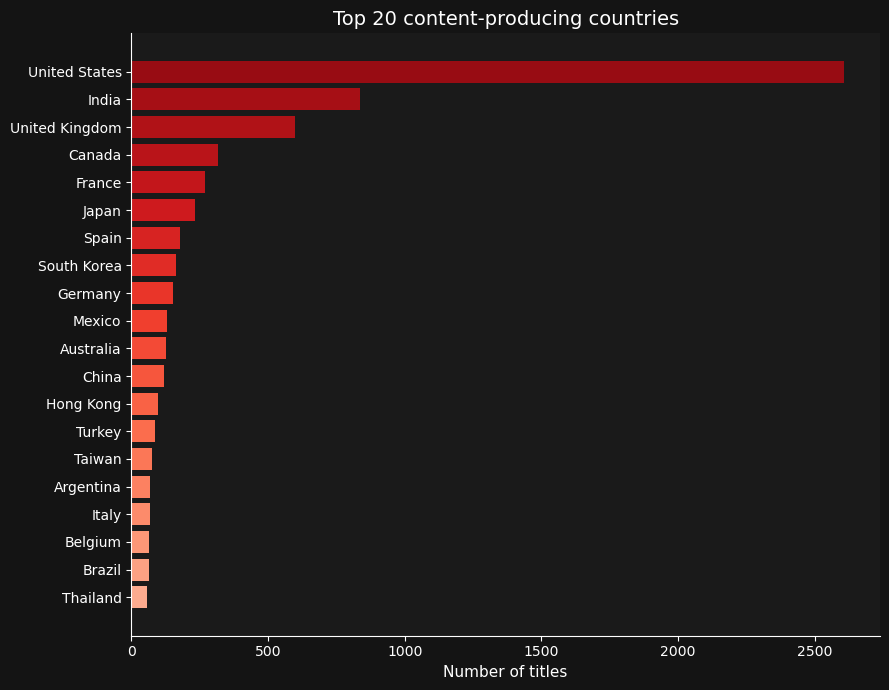

In [43]:
# ── 4d. Top 20 countries ───────────────────────────────────────────

top_countries = (
    gold_country.groupby("country")["title_count"].sum()
    .sort_values(ascending=True).tail(20)
)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_countries)))
ax.barh(top_countries.index, top_countries.values, color=colors)
ax.set_xlabel("Number of titles")
ax.set_title("Top 20 content-producing countries")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


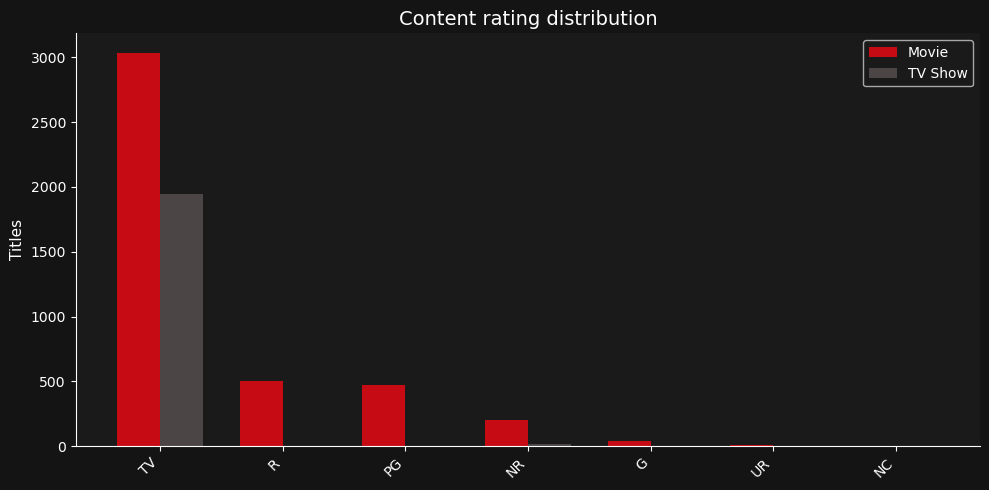

In [44]:
# ── 4e. Rating distribution ─────────────────────────────────────────

rating_data = silver.dropna(subset=["rating"])
rating_order = rating_data["rating"].value_counts().index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
movies = rating_data[rating_data["type"] == "Movie"]["rating"].value_counts().reindex(rating_order, fill_value=0)
shows = rating_data[rating_data["type"] == "TV Show"]["rating"].value_counts().reindex(rating_order, fill_value=0)

x = np.arange(len(rating_order))
w = 0.35
ax.bar(x - w/2, movies.values, w, label="Movie", color=NETFLIX_RED, alpha=0.85)
ax.bar(x + w/2, shows.values, w, label="TV Show", color=NETFLIX_GRAY, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(rating_order, rotation=45, ha="right")
ax.set_ylabel("Titles")
ax.set_title("Content rating distribution")
ax.legend()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


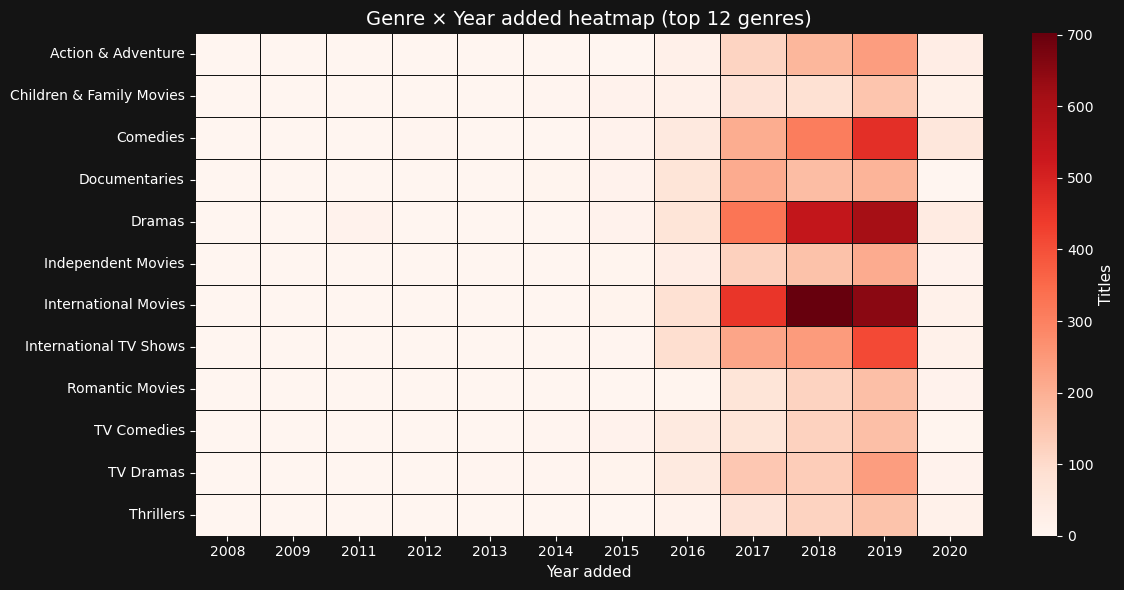

In [45]:
# ── 4f. Content age heatmap ─────────────────────────────────────────

heatmap_data = (
    genre_exploded
    .groupby(["genre", "year_added"])["show_id"].nunique()
    .reset_index()
    .rename(columns={"show_id": "count"})
)

top12 = genre_exploded["genre"].value_counts().head(12).index.tolist()
hm = heatmap_data[heatmap_data["genre"].isin(top12)].pivot_table(
    index="genre", columns="year_added", values="count", fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(hm, cmap="Reds", linewidths=0.5, linecolor="#141414", ax=ax, cbar_kws={"label": "Titles"})
ax.set_title("Genre × Year added heatmap (top 12 genres)")
ax.set_xlabel("Year added")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


---
## 5 · Content-Based Recommendation Engine
**Approach:** We combine TF-IDF vectors from descriptions with one-hot encoded genre tags, then compute cosine similarity. This mirrors a real production content-based recommender (collaborative filtering requires user interaction data we don't have).

**Why this matters commercially:** A lightweight content-similarity engine can power:
- "Because you watched X" carousels
- Similar-title search for content acquisition teams
- Automated content tagging / clustering

In [46]:
# ── 5a. Build feature matrix ───────────────────────────────────────

rec_df = silver[["show_id", "title_clean", "type", "description", "genre_list",
                 "director_list", "cast_list", "rating", "release_year"]].copy()

# Fill missing descriptions
rec_df["description"] = rec_df["description"].fillna("").astype(str)

# Combine text features into a single "soup"
rec_df["soup"] = (
    rec_df["description"] + " " +
    rec_df["genre_list"].apply(lambda x: " ".join(x)) + " " +
    rec_df["director_list"].apply(lambda x: " ".join(x[:3])) + " " +    # top 3 directors
    rec_df["rating"].fillna("")
)

# TF-IDF on the soup
tfidf = TfidfVectorizer(stop_words="english", max_features=8000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(rec_df["soup"])

# Genre one-hot encoding
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(rec_df["genre_list"])

# Combine: 70% TF-IDF, 30% genre signal (tunable)
from scipy.sparse import hstack, csr_matrix
combined_matrix = hstack([tfidf_matrix * 0.7, csr_matrix(genre_matrix) * 0.3])

print(f"Feature matrix: {combined_matrix.shape}")
print(f"  TF-IDF features:  {tfidf_matrix.shape[1]}")
print(f"  Genre features:   {genre_matrix.shape[1]}")
print(f"  Combined:         {combined_matrix.shape[1]}")

Feature matrix: (6233, 8042)
  TF-IDF features:  8000
  Genre features:   42
  Combined:         8042


In [53]:
# ── 5b. Recommendation function ────────────────────────────────────

# Pre-compute cosine similarity is expensive for 6K titles — we do it on-the-fly
# for a query set instead (much more memory-efficient and production-realistic).

def recommend(title: str, n: int = 10, content_type: str = None) -> pd.DataFrame:
    """
    Given a title (or partial match), return top-N similar titles.

    Parameters
    ----------
    title : str          Exact or partial title to match
    n : int              Number of recommendations
    content_type : str   Filter to 'Movie' or 'TV Show' (optional)

    Returns
    -------
    DataFrame with columns: title, type, genre, similarity_score, release_year
    """
    # Fuzzy match: find the best matching title
    mask = rec_df["title_clean"].str.contains(title, case=False, na=False)
    matches = rec_df[mask]

    if matches.empty:
        print(f"❌ No title found matching '{title}'")
        return pd.DataFrame()

    idx = matches.index[0]
    chosen_title = rec_df.loc[idx, "title_clean"]

    # Compute similarity of this title vs all others
    query_vec = combined_matrix[idx].toarray()
    sim_scores = cosine_similarity(query_vec, combined_matrix).flatten()

    # Build results
    results = rec_df.copy()
    results["similarity"] = sim_scores
    results = results[results.index != idx]  # exclude the query title itself

    if content_type:
        results = results[results["type"] == content_type]

    results = results.sort_values("similarity", ascending=False).head(n)

    output = results[["title_clean", "type", "genre_list", "similarity", "release_year"]].copy()
    output.columns = ["Title", "Type", "Genres", "Similarity", "Year"]
    output["Genres"] = output["Genres"].apply(lambda x: ", ".join(x[:3]))
    output["Similarity"] = output["Similarity"].round(4)
    output = output.reset_index(drop=True)
    output.index = output.index + 1  # 1-indexed for readability

    print(f"\n🎬 Because you liked: \"{chosen_title}\"\n")
    return output


# Test it
recommend("Stranger", n=10)


🎬 Because you liked: "Beyond Stranger Things"



,Title,Type,Genres,Similarity,Year
1,The 4400,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4657,2007
2,Sense8,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4419,2018
3,Nightflyers,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",0.4373,2018
4,The Vampire Diaries,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4130,2017
5,Zoo,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4123,2017
6,The Umbrella Academy,TV Show,"TV Action & Adventure, TV Mysteries, TV Sci-Fi...",0.4106,2019
7,The Messengers,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4090,2015
8,The OA,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4063,2019
9,Chilling Adventures of Sabrina,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",0.3949,2019
10,Helix,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",0.3935,2015


In [54]:
# ── 5c. Multi-title recommendation (blend) ────────────────────────

def recommend_from_multiple(titles: list, n: int = 15, content_type: str = None) -> pd.DataFrame:
    """
    Given a list of titles the user likes, average their vectors and
    find the most similar titles in the catalog.
    """
    indices = []
    found_titles = []
    for t in titles:
        mask = rec_df["title_clean"].str.contains(t, case=False, na=False)
        if mask.any():
            idx = rec_df[mask].index[0]
            indices.append(idx)
            found_titles.append(rec_df.loc[idx, "title_clean"])

    if not indices:
        print("❌ None of the titles matched.")
        return pd.DataFrame()

    # Average the feature vectors
    avg_vec = np.asarray(combined_matrix[indices].mean(axis=0))
    sim_scores = cosine_similarity(avg_vec, combined_matrix).flatten()

    results = rec_df.copy()
    results["similarity"] = sim_scores
    results = results[~results.index.isin(indices)]

    if content_type:
        results = results[results["type"] == content_type]

    results = results.sort_values("similarity", ascending=False).head(n)

    output = results[["title_clean", "type", "genre_list", "similarity", "release_year"]].copy()
    output.columns = ["Title", "Type", "Genres", "Similarity", "Year"]
    output["Genres"] = output["Genres"].apply(lambda x: ", ".join(x[:3]))
    output["Similarity"] = output["Similarity"].round(4)
    output = output.reset_index(drop=True)
    output.index += 1

    print(f"🎬 Recommendations based on: {found_titles}\n")
    return output


recommend_from_multiple(["Breaking Bad", "Narcos", "Ozark"], n=10)

🎬 Recommendations based on: ['The Road to El Camino: Behind the Scenes of El Camino: A Breaking Bad Movie', 'Narcos: Mexico', 'Ozark']



,Title,Type,Genres,Similarity,Year
1,Ultimate Beastmaster México,TV Show,"Reality TV, Spanish-Language TV Shows",0.5795,2018
2,El Chapo,TV Show,"Crime TV Shows, Spanish-Language TV Shows, TV ...",0.4788,2018
3,Narcos,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.3999,2017
4,El señor de los Cielos,TV Show,"Crime TV Shows, Spanish-Language TV Shows, TV ...",0.3903,2018
5,Enemigo íntimo,TV Show,"Crime TV Shows, Spanish-Language TV Shows, TV ...",0.3615,2018
6,El desconocido,TV Show,"Crime TV Shows, International TV Shows, Spanis...",0.3596,2019
7,Queen of the South,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.3499,2018
8,Falsa identidad,TV Show,"Crime TV Shows, Spanish-Language TV Shows, TV ...",0.3467,2018
9,Marvel's Luke Cage,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.3290,2018
10,Marvel's Jessica Jones,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.3235,2019


---
## 6 · Interactive Recommendation UI
Pick up to 5 titles from the catalog, select filters, and get instant recommendations.
Uses `ipywidgets` — works in Jupyter Notebook and JupyterLab.

In [55]:
# ── Interactive recommendation UI ─────────────────────────────────
# NOTE: ipywidgets require a live Jupyter kernel.
# On GitHub, this cell won't render — the static demo below shows output.

try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output

    all_titles = sorted(rec_df["title_clean"].dropna().unique().tolist())
    style = {"description_width": "100px"}

    title_selectors = [
        widgets.Combobox(
            placeholder=f"Type to search title {i+1}…",
            options=all_titles,
            description=f"Title {i+1}:",
            style=style,
            layout=widgets.Layout(width="500px"),
            ensure_option=False
        )
        for i in range(5)
    ]

    type_filter = widgets.Dropdown(
        options=["Any", "Movie", "TV Show"], value="Any",
        description="Type:", style=style
    )
    n_results = widgets.IntSlider(
        value=10, min=5, max=30, step=5,
        description="Results:", style=style
    )
    run_btn = widgets.Button(
        description="🔍  Get Recommendations",
        button_style="danger",
        layout=widgets.Layout(width="250px", height="40px")
    )
    output_area = widgets.Output()

    def on_click(btn):
        with output_area:
            clear_output(wait=True)
            chosen = [s.value.strip() for s in title_selectors if s.value.strip()]
            if not chosen:
                print("⚠️  Select at least one title.")
                return
            ct = None if type_filter.value == "Any" else type_filter.value
            result = recommend_from_multiple(chosen, n=n_results.value, content_type=ct)
            if not result.empty:
                display(result.style.background_gradient(subset=["Similarity"], cmap="Reds"))

    run_btn.on_click(on_click)
    display(HTML("<h3 style='color:#E50914;'>🎬 Netflix Recommendation Finder</h3>"))
    display(HTML("<p>Type a title (partial match works), pick up to 5, then click the button.</p>"))
    display(widgets.VBox(title_selectors + [widgets.HBox([type_filter, n_results]), run_btn, output_area]))

except ImportError:
    print("⚠️  ipywidgets not installed. Run: pip install ipywidgets")


In [56]:
# ── Static demo (visible on GitHub without widgets) ─────────────────

print("=" * 70)
print("  RECOMMENDATION ENGINE — STATIC DEMO")
print("=" * 70)

print("\n▸ Single title lookup: 'Stranger Things'")
display(recommend("Stranger", n=8))

print("\n▸ Multi-title blend: Breaking Bad + Narcos + Ozark")
display(recommend_from_multiple(["Breaking Bad", "Narcos", "Ozark"], n=8))


  RECOMMENDATION ENGINE — STATIC DEMO

▸ Single title lookup: 'Stranger Things'

🎬 Because you liked: "Beyond Stranger Things"



,Title,Type,Genres,Similarity,Year
1,The 4400,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4657,2007
2,Sense8,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4419,2018
3,Nightflyers,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",0.4373,2018
4,The Vampire Diaries,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4130,2017
5,Zoo,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4123,2017
6,The Umbrella Academy,TV Show,"TV Action & Adventure, TV Mysteries, TV Sci-Fi...",0.4106,2019
7,The Messengers,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4090,2015
8,The OA,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.4063,2019



▸ Multi-title blend: Breaking Bad + Narcos + Ozark
🎬 Recommendations based on: ['The Road to El Camino: Behind the Scenes of El Camino: A Breaking Bad Movie', 'Narcos: Mexico', 'Ozark']



,Title,Type,Genres,Similarity,Year
1,Ultimate Beastmaster México,TV Show,"Reality TV, Spanish-Language TV Shows",0.5795,2018
2,El Chapo,TV Show,"Crime TV Shows, Spanish-Language TV Shows, TV ...",0.4788,2018
3,Narcos,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.3999,2017
4,El señor de los Cielos,TV Show,"Crime TV Shows, Spanish-Language TV Shows, TV ...",0.3903,2018
5,Enemigo íntimo,TV Show,"Crime TV Shows, Spanish-Language TV Shows, TV ...",0.3615,2018
6,El desconocido,TV Show,"Crime TV Shows, International TV Shows, Spanis...",0.3596,2019
7,Queen of the South,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.3499,2018
8,Falsa identidad,TV Show,"Crime TV Shows, Spanish-Language TV Shows, TV ...",0.3467,2018


---
## 7 · Genre Similarity Explorer
A visual map of how genres cluster together based on the titles they share.

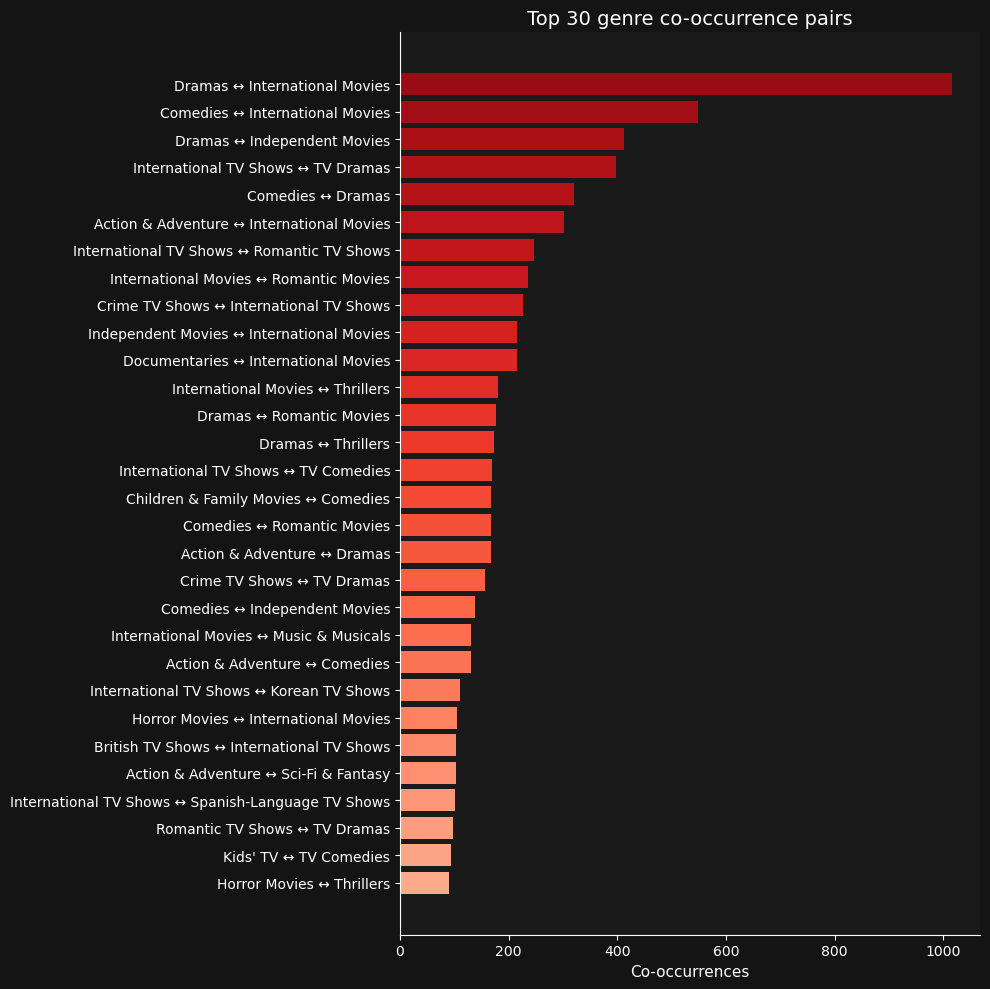

In [57]:
# ── Genre co-occurrence matrix ──────────────────────────────────────

from itertools import combinations

genre_pairs = []
for genres in silver["genre_list"]:
    if len(genres) >= 2:
        for a, b in combinations(sorted(set(g.strip() for g in genres)), 2):
            genre_pairs.append((a, b))

pair_df = pd.DataFrame(genre_pairs, columns=["genre_a", "genre_b"])
cooccurrence = pair_df.groupby(["genre_a", "genre_b"]).size().reset_index(name="count")
top_pairs = cooccurrence.sort_values("count", ascending=False).head(30)
top_pairs["pair"] = top_pairs["genre_a"] + " ↔ " + top_pairs["genre_b"]

fig, ax = plt.subplots(figsize=(10, 10))
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_pairs)))
ax.barh(top_pairs["pair"].values[::-1], top_pairs["count"].values[::-1], color=colors)
ax.set_xlabel("Co-occurrences")
ax.set_title("Top 30 genre co-occurrence pairs")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


---
## 8 · Content Gap Analysis (the actual business insight)
This section answers: **Where should Netflix invest next?**

We look at:
- Genres that are growing in demand (recent additions trending up) but have low catalog depth
- Countries producing content that Netflix under-represents
- Rating segments with opportunity

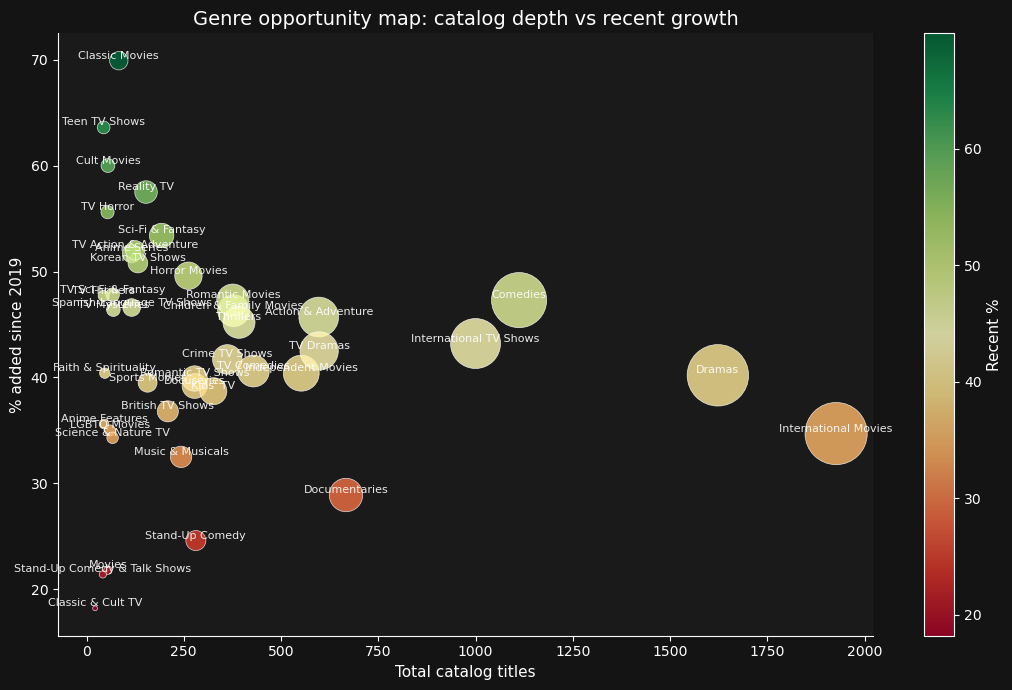


📌 TOP-LEFT quadrant = biggest content gaps (high growth, thin catalog).


In [58]:
# ── Genre growth rate vs catalog depth ─────────────────────────────

recent = genre_exploded[genre_exploded["year_added"] >= 2019].copy()
recent_counts = recent.groupby("genre")["show_id"].nunique().reset_index(name="recent_additions")
total_counts = genre_exploded.groupby("genre")["show_id"].nunique().reset_index(name="total_titles")

gap = recent_counts.merge(total_counts, on="genre")
gap["recent_pct"] = (gap["recent_additions"] / gap["total_titles"] * 100).round(1)
gap = gap[gap["total_titles"] >= 20]

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    gap["total_titles"], gap["recent_pct"],
    s=gap["recent_additions"] * 3,
    c=gap["recent_pct"], cmap="RdYlGn",
    alpha=0.8, edgecolors="white", linewidths=0.5
)
for _, row in gap.iterrows():
    ax.annotate(row["genre"], (row["total_titles"], row["recent_pct"]),
                fontsize=8, ha="center", va="bottom", color="white", alpha=0.9)
ax.set_xlabel("Total catalog titles")
ax.set_ylabel("% added since 2019")
ax.set_title("Genre opportunity map: catalog depth vs recent growth")
plt.colorbar(scatter, ax=ax, label="Recent %")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print("\n📌 TOP-LEFT quadrant = biggest content gaps (high growth, thin catalog).")


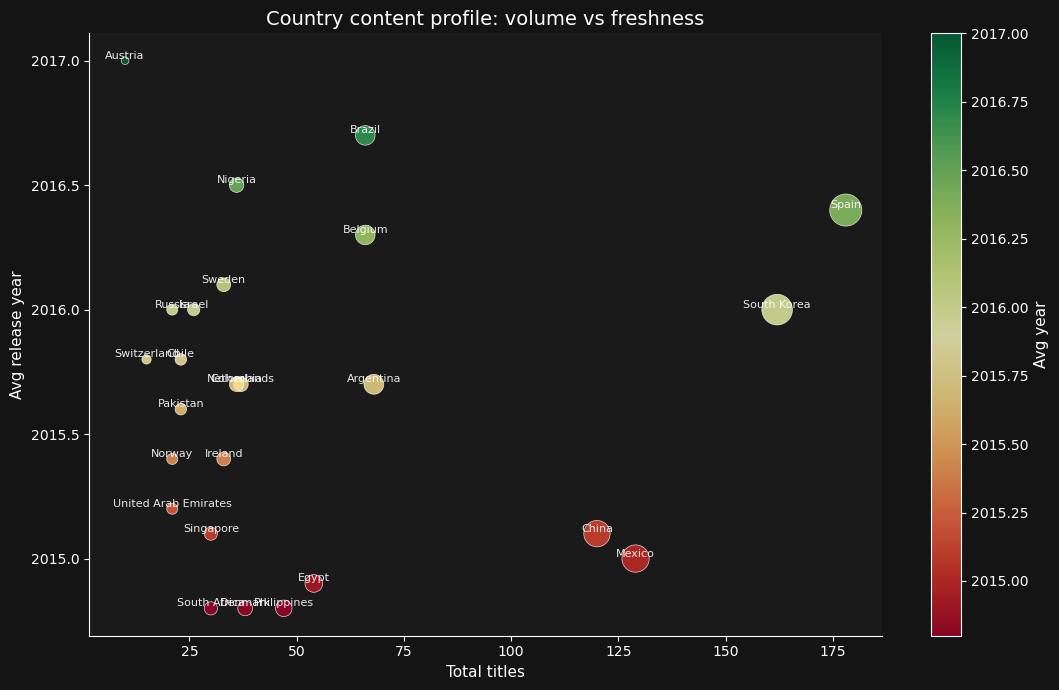


📌 BOTTOM-RIGHT = stale catalogs. TOP-LEFT = emerging markets.


In [59]:
# ── Country-level content freshness ────────────────────────────────

country_fresh = (
    country_exploded
    .groupby("country")
    .agg(total=("show_id", "nunique"), avg_release_year=("release_year", "mean"))
    .reset_index()
    .query("total >= 10")
    .sort_values("avg_release_year", ascending=False)
    .head(25)
)
country_fresh["avg_release_year"] = country_fresh["avg_release_year"].round(1)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    country_fresh["total"], country_fresh["avg_release_year"],
    s=country_fresh["total"] * 3,
    c=country_fresh["avg_release_year"], cmap="RdYlGn",
    alpha=0.8, edgecolors="white", linewidths=0.5
)
for _, row in country_fresh.iterrows():
    ax.annotate(row["country"], (row["total"], row["avg_release_year"]),
                fontsize=8, ha="center", va="bottom", color="white", alpha=0.9)
ax.set_xlabel("Total titles")
ax.set_ylabel("Avg release year")
ax.set_title("Country content profile: volume vs freshness")
plt.colorbar(scatter, ax=ax, label="Avg year")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print("\n📌 BOTTOM-RIGHT = stale catalogs. TOP-LEFT = emerging markets.")


---
## 9 · Pipeline Summary & Next Steps

### What we built
| Layer | What | Format |
|-------|------|--------|
| **Bronze** | Raw CSV → Parquet with lineage metadata | `.parquet` |
| **Silver** | Cleaned, joined, feature-engineered enriched table | `.parquet` |
| **Gold** | Pre-aggregated analytics tables (genre trends, country volume, freshness, ratings) | `.parquet` |
| **ML** | Content-based recommendation engine (TF-IDF + genre one-hot, cosine similarity) | In-memory / serializable |
| **UI** | Interactive ipywidgets recommender + Plotly dashboards | Jupyter-native |

### To productionize / commercialize
1. **Swap data source** → Replace static CSVs with Netflix API / TMDB API for live catalog data
2. **Add collaborative filtering** → Once you have user interaction data (watches, ratings), hybrid rec models outperform content-based alone
3. **Deploy the recommender** → Wrap `recommend()` in a FastAPI endpoint, deploy on AWS/GCP
4. **Schedule the pipeline** → Use Airflow / Prefect to run Bronze→Silver→Gold daily
5. **Add a real frontend** → React/Next.js app consuming the FastAPI recommendation endpoint
6. **A/B testing** → Measure click-through on recommendations vs Netflix's native suggestions

---
*Pipeline built with Python, Pandas, Scikit-learn, Plotly, and ipywidgets. No cloud dependency — runs anywhere.*
